# Customer Personality Analysis — Model Building & Evaluation

**Objective:** Segment customers into distinct groups using K-Means clustering to enable targeted marketing strategies.

**Input:** `customer_segmentation_model_ready.csv` (2236 rows, 12 features — output from EDA notebook)

**Pipeline:** Load Data → StandardScaler → Find Optimal K → K-Means Clustering → Evaluate → Cluster Profiling → Save Model

---

## Step 1: Setup & Load Data

In [63]:
# Load the model-ready dataset from EDA
df = pd.read_csv('customer_segmentation_model_ready.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Features: {df.columns.tolist()}')
df.head()

Dataset Shape: (2236, 12)
Features: ['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Age', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 'Total_Campaigns_Accepted']


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Age,Total_Spend,Total_Purchases,Total_Dependents,Total_Campaigns_Accepted
0,1,1,58138.0,58,3,7,1,69,1617,22,0,0
1,1,1,46344.0,38,2,5,0,72,27,4,2,0
2,1,0,71613.0,26,1,4,0,61,776,20,0,0
3,1,0,26646.0,26,2,6,0,42,53,6,1,0
4,2,0,58293.0,94,5,5,0,45,422,14,1,0


In [64]:
# Quick sanity check
print('Missing values:', df.isnull().sum().sum())
print('\nDescriptive stats:')
df.describe().T.round(2)

Missing values: 0

Descriptive stats:


,count,mean,std,min,25%,50%,75%,max
Education,2236.0,1.27,0.65,0.0,1.0,1.0,2.00,2.0
Marital_Status,2236.0,0.36,0.48,0.0,0.0,0.0,1.00,1.0
Income,2236.0,51952.61,21411.47,1730.0,35502.5,51381.5,68275.75,162397.0
Recency,2236.0,49.12,28.96,0.0,24.0,49.0,74.00,99.0
NumDealsPurchases,2236.0,2.33,1.93,0.0,1.0,2.0,3.00,15.0
NumWebVisitsMonth,2236.0,5.32,2.43,0.0,3.0,6.0,7.00,20.0
Response,2236.0,0.15,0.36,0.0,0.0,0.0,0.00,1.0
Age,2236.0,57.10,11.70,30.0,49.0,56.0,67.00,86.0
Total_Spend,2236.0,605.99,601.87,5.0,69.0,396.5,1045.50,2525.0
Total_Purchases,2236.0,12.55,7.21,0.0,6.0,12.0,18.00,32.0


## Step 2: Feature Scaling (StandardScaler)

K-Means uses Euclidean distance — features with larger scales (Income: 1,730–162,397) would dominate over smaller ones (Response: 0–1). StandardScaler converts all features to mean=0, std=1 so every feature contributes equally.

In [65]:
# Scale all features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Verify scaling
scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print('After scaling (should be mean≈0, std≈1):')
print(scaled_df.describe().T[['mean', 'std']].round(4))

After scaling (should be mean≈0, std≈1):
                          mean     std
Education                  0.0  1.0002
Marital_Status            -0.0  1.0002
Income                    -0.0  1.0002
Recency                   -0.0  1.0002
NumDealsPurchases          0.0  1.0002
NumWebVisitsMonth         -0.0  1.0002
Response                  -0.0  1.0002
Age                        0.0  1.0002
Total_Spend                0.0  1.0002
Total_Purchases            0.0  1.0002
Total_Dependents           0.0  1.0002
Total_Campaigns_Accepted  -0.0  1.0002


## Step 3: Find Optimal Number of Clusters (K)

We use two methods:
- **Elbow Method** — plots inertia (within-cluster sum of squares) for each K. Look for the "bend" where adding clusters stops helping significantly.
- **Silhouette Score** — measures how well each customer fits their cluster vs neighboring clusters (-1 to +1, higher = better).

In [66]:
# Test K from 2 to 10
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f'K={k}: Inertia={km.inertia_:.1f}, Silhouette={silhouette_score(X_scaled, labels):.4f}')

K=2: Inertia=20679.7, Silhouette=0.2227
K=3: Inertia=18741.7, Silhouette=0.1581
K=4: Inertia=17135.9, Silhouette=0.1783
K=5: Inertia=16068.4, Silhouette=0.1535
K=6: Inertia=15223.4, Silhouette=0.1547
K=7: Inertia=14504.6, Silhouette=0.1331
K=8: Inertia=13851.5, Silhouette=0.1310
K=9: Inertia=13392.9, Silhouette=0.1309
K=10: Inertia=12890.2, Silhouette=0.1371


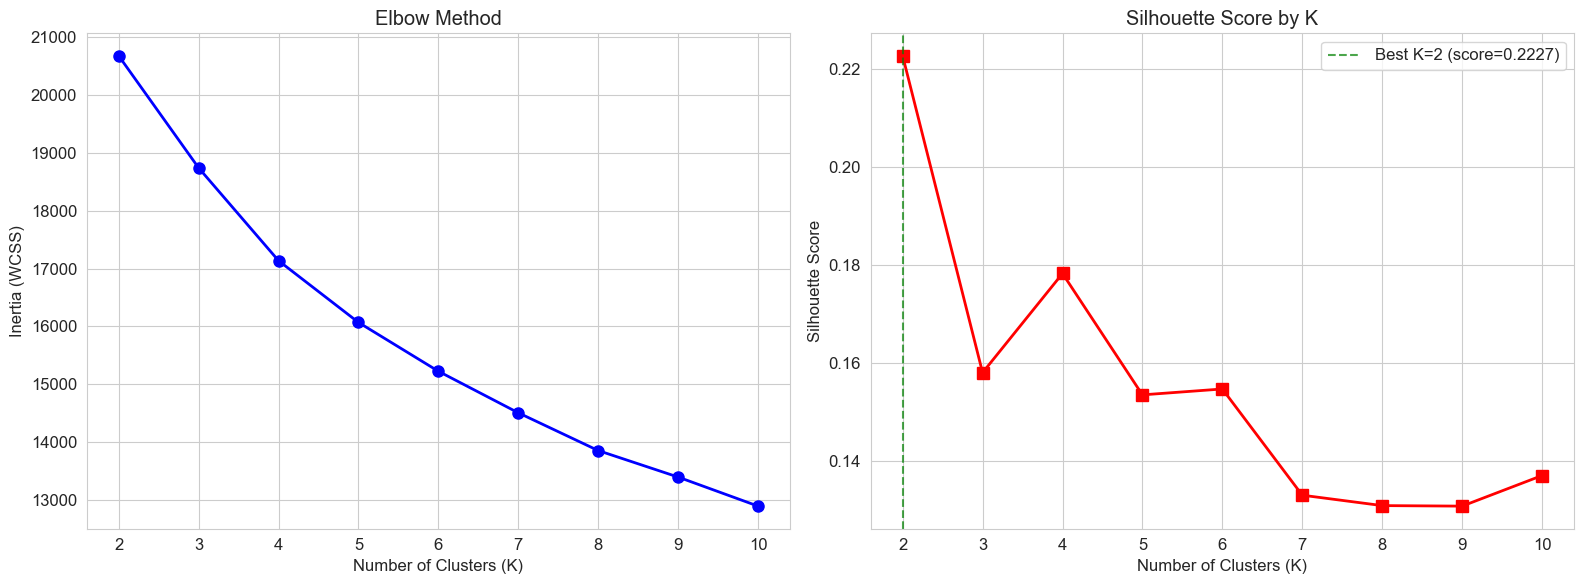


Best K by Silhouette Score: 2


In [67]:
# Plot Elbow Method and Silhouette Score side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

# Silhouette Score
axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xticks(list(K_range))

# Highlight the best silhouette
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7, 
                label=f'Best K={best_k_sil} (score={max(sil_scores):.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBest K by Silhouette Score: {best_k_sil}')

### Comparing Candidate K Values

The silhouette score alone isn't enough — we need clusters that are **business-actionable**. Let's compare K=2, 3, and 4 by looking at the actual customer profiles in each.

In [68]:
# Compare K=2, 3, 4 — look at actual cluster profiles
candidate_ks = [2, 3, 4]

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    
    print(f'\n{"="*70}')
    print(f'K = {k}  |  Silhouette Score: {sil:.4f}')
    print(f'{"="*70}')
    
    temp_df = df.copy()
    temp_df['Cluster'] = labels
    
    for c in range(k):
        cdata = temp_df[temp_df['Cluster'] == c]
        print(f'  Cluster {c} ({len(cdata):4d} customers | {len(cdata)/len(temp_df)*100:5.1f}%): '
              f'Income=${cdata["Income"].mean():,.0f}  '
              f'Spend=${cdata["Total_Spend"].mean():,.0f}  '
              f'Purchases={cdata["Total_Purchases"].mean():.1f}  '
              f'Dependents={cdata["Total_Dependents"].mean():.1f}  '
              f'Campaigns={cdata["Total_Campaigns_Accepted"].mean():.2f}')


K = 2  |  Silhouette Score: 0.2227
  Cluster 0 (1325 customers |  59.3%): Income=$38,245  Spend=$193  Purchases=7.8  Dependents=1.3  Campaigns=0.11
  Cluster 1 ( 911 customers |  40.7%): Income=$71,889  Spend=$1,207  Purchases=19.4  Dependents=0.5  Campaigns=0.58

K = 3  |  Silhouette Score: 0.1581
  Cluster 0 (1030 customers |  46.1%): Income=$34,209  Spend=$103  Purchases=6.0  Dependents=1.2  Campaigns=0.09
  Cluster 1 ( 557 customers |  24.9%): Income=$76,767  Spend=$1,373  Purchases=19.1  Dependents=0.1  Campaigns=0.82
  Cluster 2 ( 649 customers |  29.0%): Income=$58,816  Spend=$746  Purchases=17.3  Dependents=1.2  Campaigns=0.19

K = 4  |  Silhouette Score: 0.1783
  Cluster 0 ( 409 customers |  18.3%): Income=$52,515  Spend=$605  Purchases=15.2  Dependents=1.5  Campaigns=0.21
  Cluster 1 ( 973 customers |  43.5%): Income=$34,054  Spend=$97  Purchases=5.8  Dependents=1.2  Campaigns=0.08
  Cluster 2 ( 627 customers |  28.0%): Income=$70,207  Spend=$1,066  Purchases=18.7  Dependent

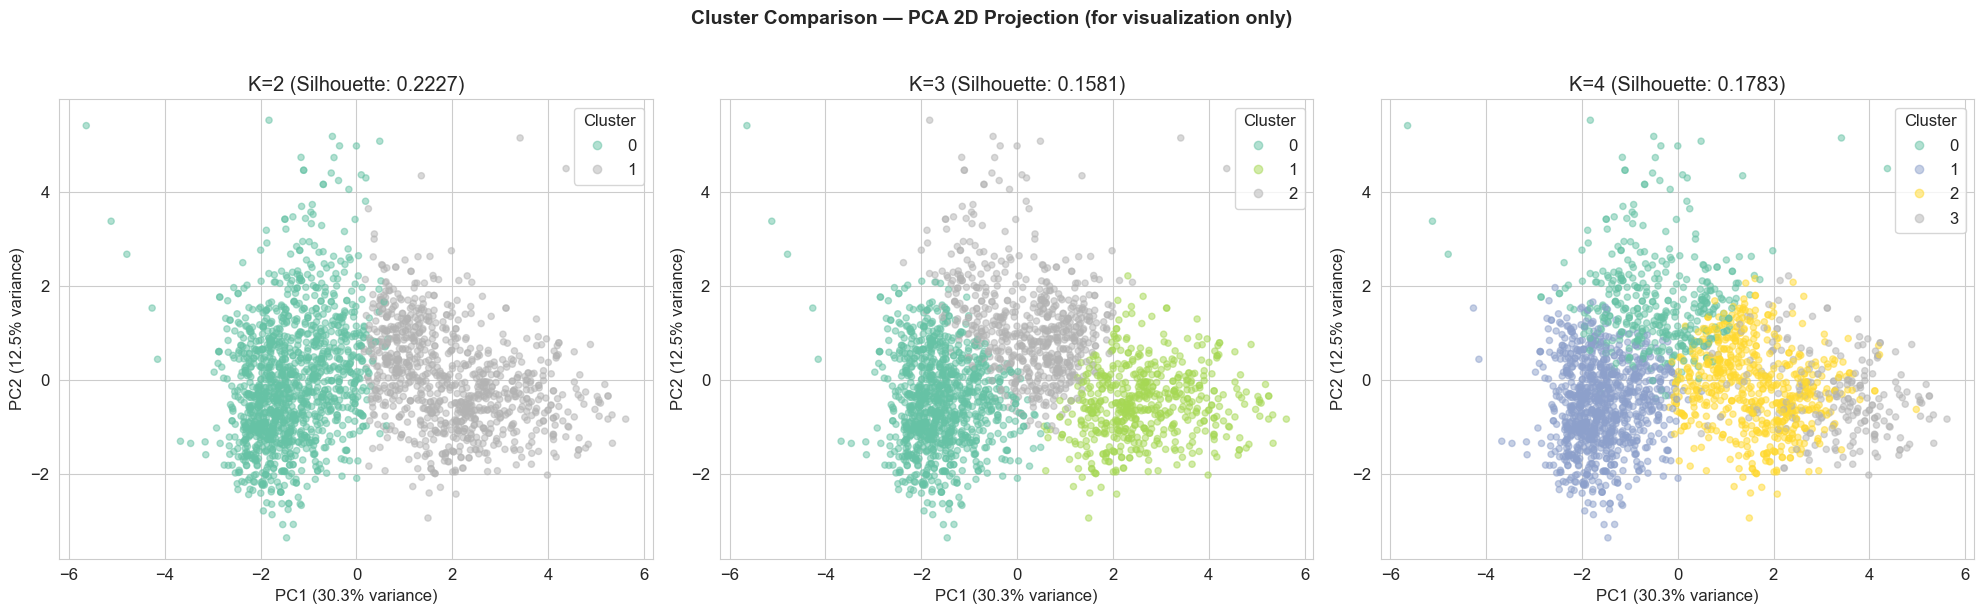

In [69]:
# Visualize all three K candidates side by side using PCA for 2D projection
# PCA is used ONLY for visualization here, not for the clustering pipeline
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, k in enumerate(candidate_ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, 
                                 cmap='Set2', alpha=0.5, s=20)
    axes[idx].set_title(f'K={k} (Silhouette: {silhouette_score(X_scaled, labels):.4f})')
    axes[idx].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
    axes[idx].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
    axes[idx].legend(*scatter.legend_elements(), title='Cluster')

plt.suptitle('Cluster Comparison — PCA 2D Projection (for visualization only)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**How to choose:** Look at the profiles above and the scatter plots. Pick the K where:
- Clusters tell **clearly different stories** (not just "slightly different" versions of each other)
- Each segment is **large enough** to target (not just 2-3% of customers)
- The scatter plot shows **visible separation** between colors

K=4 typically gives: a "Budget" group, "Average" group, "High Value" group, and "Premium Loyal" group — 4 distinct marketing strategies.

## Step 4: Run K-Means with Chosen K

Set your chosen K below based on the analysis in Step 3.

In [70]:
# ============================================
# SET YOUR CHOSEN K HERE
CHOSEN_K = 4
# ============================================

# Fit final K-Means model
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Print final results
final_sil = silhouette_score(X_scaled, df['Cluster'])
print(f'Final Model: K={CHOSEN_K}, Silhouette Score={final_sil:.4f}')
print(f'\nCluster Sizes:')
for cluster in sorted(df['Cluster'].unique()):
    count = (df['Cluster'] == cluster).sum()
    pct = count / len(df) * 100
    print(f'  Cluster {cluster}: {count} customers ({pct:.1f}%)')

Final Model: K=4, Silhouette Score=0.1783

Cluster Sizes:
  Cluster 0: 409 customers (18.3%)
  Cluster 1: 973 customers (43.5%)
  Cluster 2: 627 customers (28.0%)
  Cluster 3: 227 customers (10.2%)


## Step 5: Model Evaluation

### 5a. Silhouette Analysis

The silhouette plot shows how well each individual customer fits their assigned cluster. Wider bars = better fit, negative bars = possible misassignment.

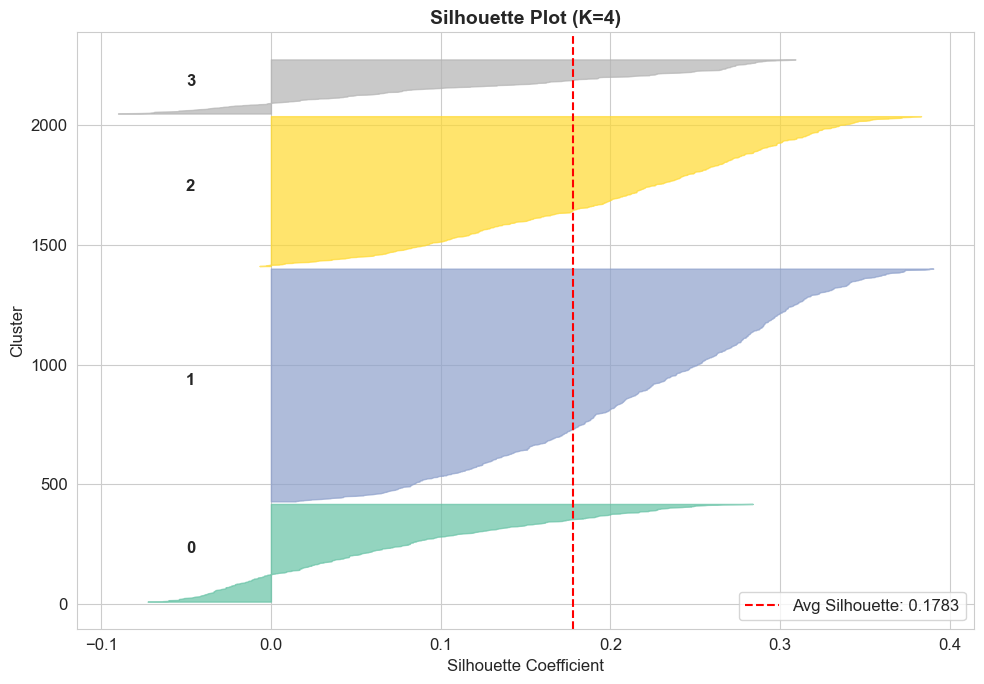

In [71]:
# Silhouette plot
sample_sil_values = silhouette_samples(X_scaled, df['Cluster'])

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
colors = plt.cm.Set2(np.linspace(0, 1, CHOSEN_K))

for i in range(CHOSEN_K):
    cluster_values = sample_sil_values[df['Cluster'] == i]
    cluster_values.sort()
    
    size = cluster_values.shape[0]
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color='red', linestyle='--', label=f'Avg Silhouette: {final_sil:.4f}')
ax.set_title(f'Silhouette Plot (K={CHOSEN_K})', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()

### 5b. Cluster Scatter Plots

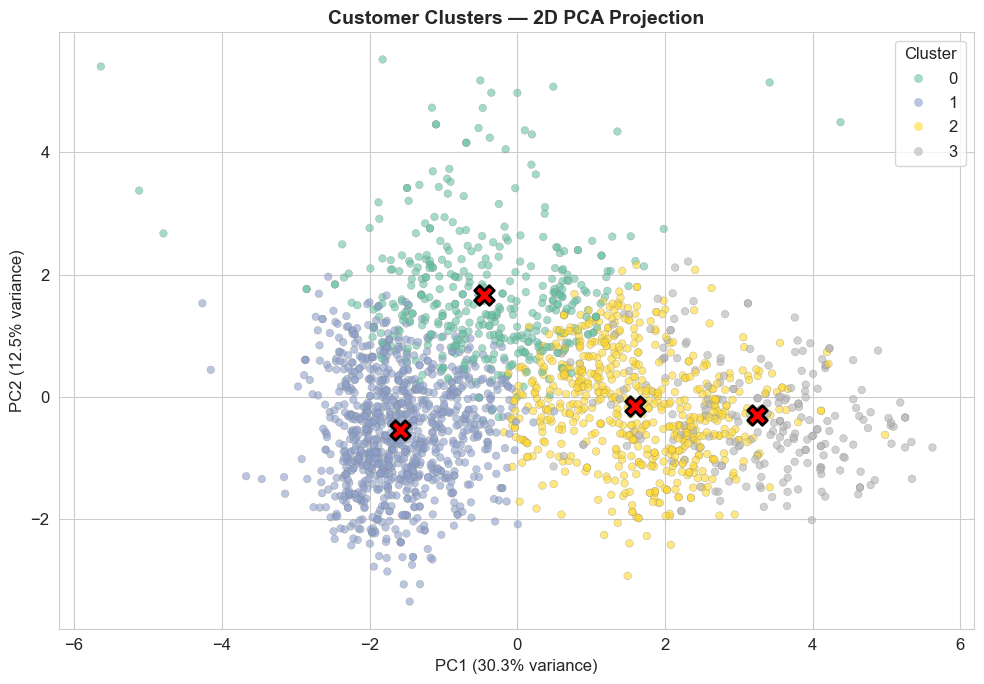

In [72]:
# 2D PCA scatter — shows overall cluster separation
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], 
                     cmap='Set2', alpha=0.6, s=30, edgecolors='gray', linewidth=0.3)

# Plot cluster centroids
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
           s=200, edgecolors='black', linewidth=2, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Customer Clusters — 2D PCA Projection', fontsize=14, fontweight='bold')
ax.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

## Step 6: Cluster Profiling

Understanding **who** is in each cluster — the business-value step.

### 6a. Cluster Means

In [73]:
# Average of all features by cluster
cluster_profile = df.groupby('Cluster').mean().round(2)
print('Cluster Profiles (Mean Values):')
print(cluster_profile.to_string())

Cluster Profiles (Mean Values):
         Education  Marital_Status    Income  Recency  NumDealsPurchases  NumWebVisitsMonth  Response    Age  Total_Spend  Total_Purchases  Total_Dependents  Total_Campaigns_Accepted
Cluster                                                                                                                                                                               
0             1.41            0.35  52514.67    49.44               5.30               6.72      0.16  60.79       604.93            15.16              1.50                      0.21
1             1.16            0.35  34054.09    48.81               1.82               6.47      0.08  54.04        97.30             5.83              1.18                      0.08
2             1.30            0.32  70207.35    52.04               1.55               3.24      0.00  59.61      1066.25            18.71              0.51                      0.22
3             1.40            0.49  77237.47    41.76

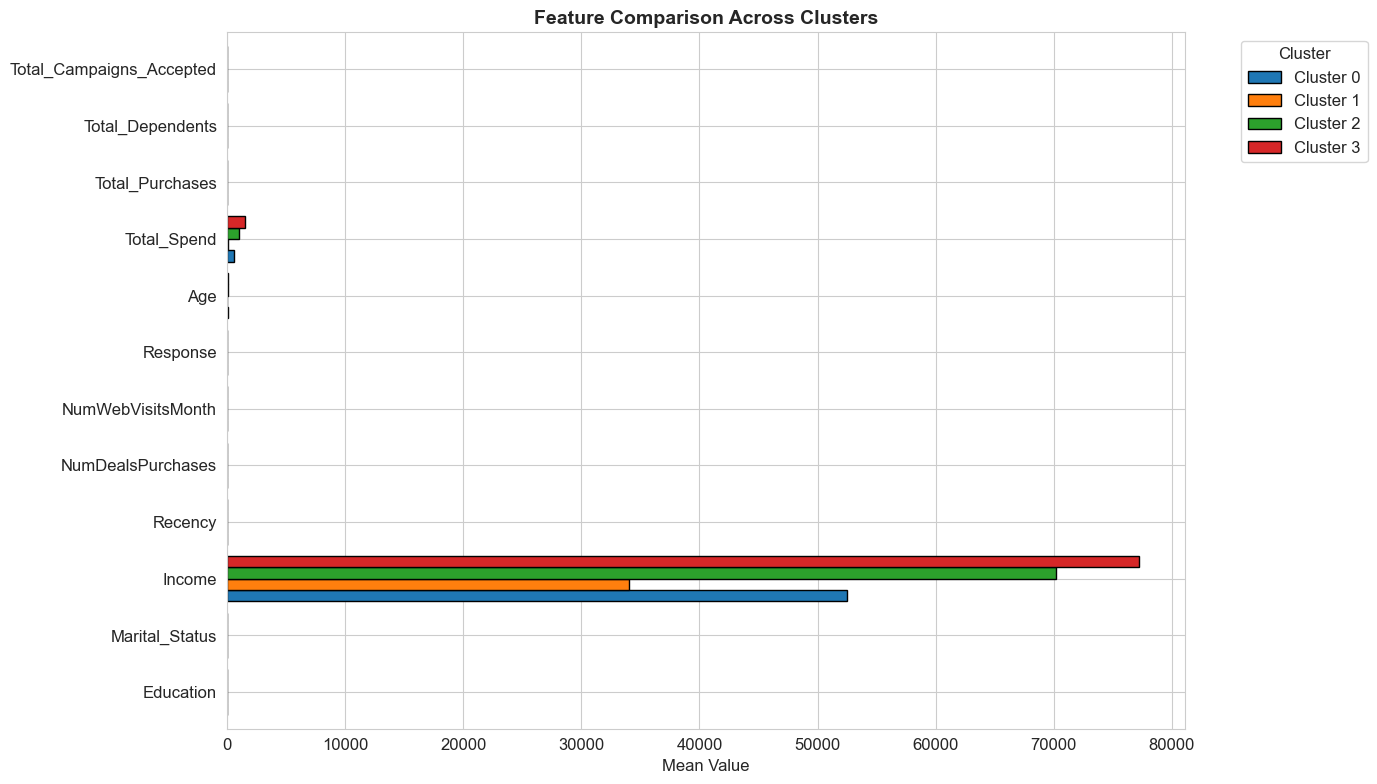

In [74]:
# Horizontal bar chart comparing all features across clusters
cluster_profile_T = cluster_profile.drop(columns=['Cluster'], errors='ignore').T
cluster_profile_T.columns = [f'Cluster {c}' for c in cluster_profile_T.columns]

fig, ax = plt.subplots(figsize=(14, 8))
cluster_profile_T.plot(kind='barh', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Feature Comparison Across Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Value')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6b. Key Metrics Comparison

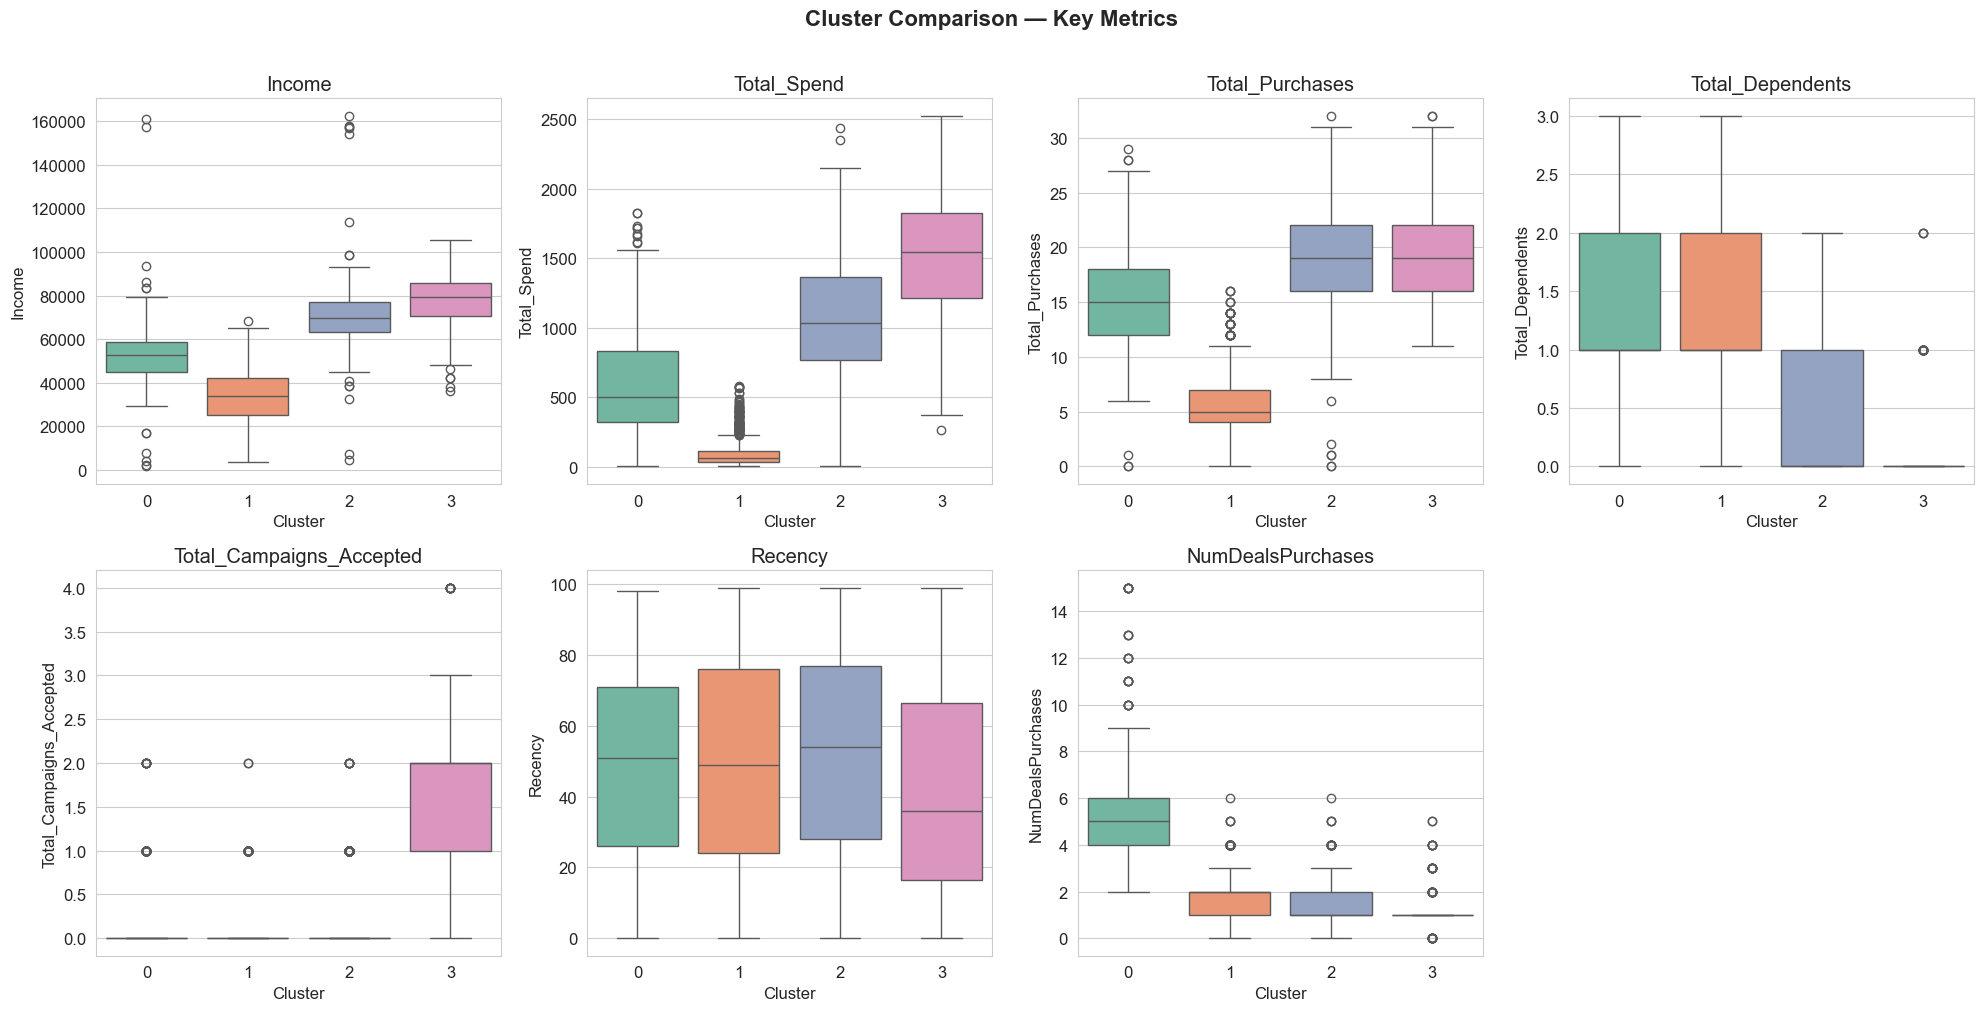

In [75]:
# Boxplots for the most important segmentation features
key_features = ['Income', 'Total_Spend', 'Total_Purchases', 'Total_Dependents',
                'Total_Campaigns_Accepted', 'Recency', 'NumDealsPurchases']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='Cluster', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

axes[-1].set_visible(False)

plt.suptitle('Cluster Comparison — Key Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6c. Cluster Size & Spending Distribution

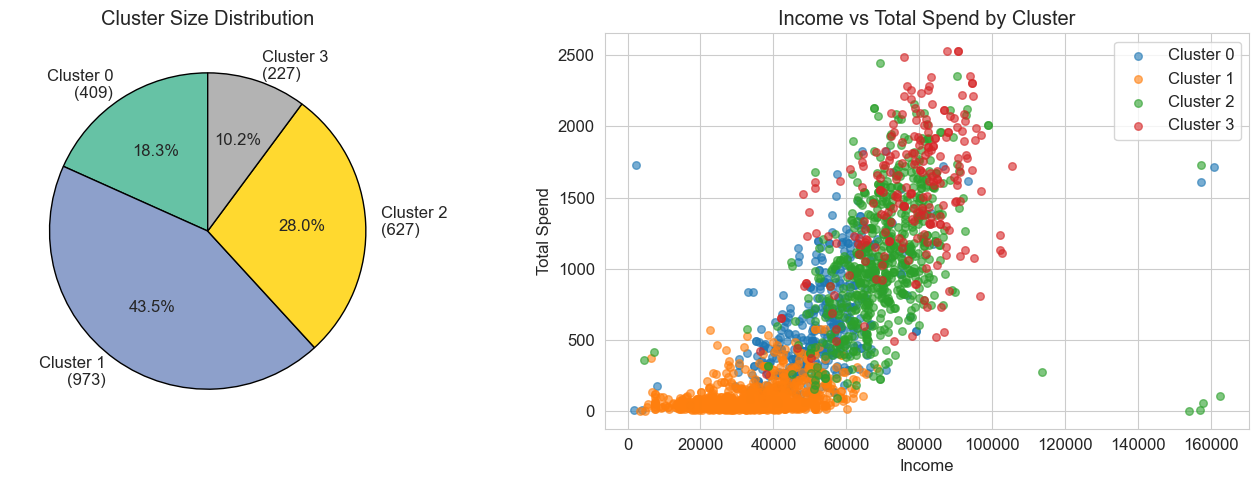

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes (pie chart)
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[0].pie(cluster_counts, labels=[f'Cluster {i}\n({count})' for i, count in cluster_counts.items()],
            autopct='%1.1f%%', colors=plt.cm.Set2(np.linspace(0, 1, CHOSEN_K)),
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Cluster Size Distribution')

# Income vs Total Spend scatter colored by cluster
for cluster in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster
    axes[1].scatter(df.loc[mask, 'Income'], df.loc[mask, 'Total_Spend'],
                    label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Spend')
axes[1].set_title('Income vs Total Spend by Cluster')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6d. Detailed Cluster Profiles & Labels

In [77]:
# Print detailed profiles for each cluster
print('='*70)
print('CLUSTER PROFILES FOR BUSINESS LABELING')
print('='*70)

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    print(f'\n--- Cluster {cluster} ({len(cluster_data)} customers, {len(cluster_data)/len(df)*100:.1f}%) ---')
    print(f'  Income:              ${cluster_data["Income"].mean():,.0f} avg')
    print(f'  Total Spend:         ${cluster_data["Total_Spend"].mean():,.0f} avg')
    print(f'  Total Purchases:     {cluster_data["Total_Purchases"].mean():.1f} avg')
    print(f'  Total Dependents:    {cluster_data["Total_Dependents"].mean():.1f} avg')
    print(f'  Campaigns Accepted:  {cluster_data["Total_Campaigns_Accepted"].mean():.2f} avg')
    print(f'  Deal Purchases:      {cluster_data["NumDealsPurchases"].mean():.1f} avg')
    print(f'  Web Visits/Month:    {cluster_data["NumWebVisitsMonth"].mean():.1f} avg')
    print(f'  Recency:             {cluster_data["Recency"].mean():.1f} days avg')
    print(f'  Last Campaign Response Rate: {cluster_data["Response"].mean()*100:.1f}%')

CLUSTER PROFILES FOR BUSINESS LABELING

--- Cluster 0 (409 customers, 18.3%) ---
  Income:              $52,515 avg
  Total Spend:         $605 avg
  Total Purchases:     15.2 avg
  Total Dependents:    1.5 avg
  Campaigns Accepted:  0.21 avg
  Deal Purchases:      5.3 avg
  Web Visits/Month:    6.7 avg
  Recency:             49.4 days avg
  Last Campaign Response Rate: 16.4%

--- Cluster 1 (973 customers, 43.5%) ---
  Income:              $34,054 avg
  Total Spend:         $97 avg
  Total Purchases:     5.8 avg
  Total Dependents:    1.2 avg
  Campaigns Accepted:  0.08 avg
  Deal Purchases:      1.8 avg
  Web Visits/Month:    6.5 avg
  Recency:             48.8 days avg
  Last Campaign Response Rate: 7.6%

--- Cluster 2 (627 customers, 28.0%) ---
  Income:              $70,207 avg
  Total Spend:         $1,066 avg
  Total Purchases:     18.7 avg
  Total Dependents:    0.5 avg
  Campaigns Accepted:  0.22 avg
  Deal Purchases:      1.6 avg
  Web Visits/Month:    3.2 avg
  Recency:      

### Automatic Cluster Labeling

Based on the profiles above, we automatically assign business labels by comparing each cluster's metrics against the overall dataset averages. The logic:

- **Income > 1.2x avg AND Spend > 1.5x avg AND Campaigns > 2x avg** → "Premium Loyal"
- **Income > 1.2x avg AND Spend > 1.5x avg** → "High-Value"  
- **Income < 0.8x avg AND Spend < 0.5x avg** → "Budget-Conscious"
- **Everything else** → "Average Mainstream"

In [78]:
# Auto-label clusters based on their profiles vs overall averages
overall_means = {
    'Income': df['Income'].mean(),
    'Total_Spend': df['Total_Spend'].mean(),
    'Total_Dependents': df['Total_Dependents'].mean(),
    'Total_Campaigns_Accepted': df['Total_Campaigns_Accepted'].mean()
}

cluster_means = df.groupby('Cluster')[list(overall_means.keys())].mean()

cluster_labels = {}
for cluster in sorted(df['Cluster'].unique()):
    m = cluster_means.loc[cluster]
    
    high_income = m['Income'] > overall_means['Income'] * 1.2
    high_spend = m['Total_Spend'] > overall_means['Total_Spend'] * 1.5
    low_income = m['Income'] < overall_means['Income'] * 0.8
    low_spend = m['Total_Spend'] < overall_means['Total_Spend'] * 0.5
    high_campaigns = m['Total_Campaigns_Accepted'] > overall_means['Total_Campaigns_Accepted'] * 2
    
    if high_income and high_spend and high_campaigns:
        label = 'Premium Loyal'
    elif high_income and high_spend:
        label = 'High-Value'
    elif low_income and low_spend:
        label = 'Budget-Conscious'
    else:
        label = 'Average Mainstream'
    
    cluster_labels[cluster] = label
    count = (df['Cluster'] == cluster).sum()
    pct = count / len(df) * 100
    print(f'Cluster {cluster} → {label:25s} ({count} customers, {pct:.1f}%)')
    print(f'           Income: ${m["Income"]:,.0f}  |  Spend: ${m["Total_Spend"]:,.0f}  |  '
          f'Dependents: {m["Total_Dependents"]:.1f}  |  Campaigns: {m["Total_Campaigns_Accepted"]:.2f}')

# Apply labels to dataframe
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

print(f'\nLabels applied successfully!')
print(f'\nCluster distribution:')
print(df['Cluster_Label'].value_counts())

Cluster 0 → Average Mainstream        (409 customers, 18.3%)
           Income: $52,515  |  Spend: $605  |  Dependents: 1.5  |  Campaigns: 0.21
Cluster 1 → Budget-Conscious          (973 customers, 43.5%)
           Income: $34,054  |  Spend: $97  |  Dependents: 1.2  |  Campaigns: 0.08
Cluster 2 → High-Value                (627 customers, 28.0%)
           Income: $70,207  |  Spend: $1,066  |  Dependents: 0.5  |  Campaigns: 0.22
Cluster 3 → Premium Loyal             (227 customers, 10.2%)
           Income: $77,237  |  Spend: $1,517  |  Dependents: 0.2  |  Campaigns: 1.59

Labels applied successfully!

Cluster distribution:
Cluster_Label
Budget-Conscious      973
High-Value            627
Average Mainstream    409
Premium Loyal         227
Name: count, dtype: int64


### 6e. Final Cluster Visualization — All Customers Labeled

The complete view of our customer segmentation — every customer plotted with their segment label.

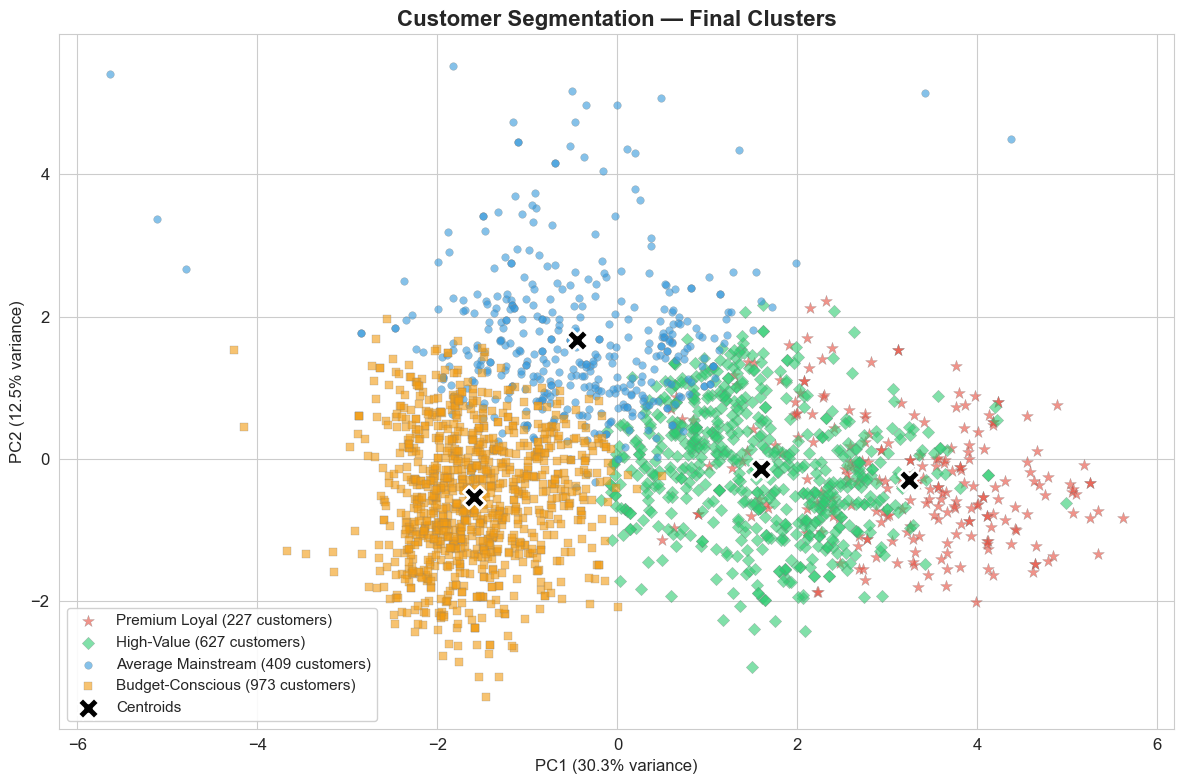

In [79]:
# Final cluster visualization — PCA 2D with business labels and styled markers
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Color and marker config for each segment
segment_styles = {
    'Premium Loyal':      {'color': '#e74c3c', 'marker': '*',  'size': 80},
    'High-Value':         {'color': '#2ecc71', 'marker': 'D',  'size': 40},
    'Average Mainstream': {'color': '#3498db', 'marker': 'o',  'size': 30},
    'Budget-Conscious':   {'color': '#f39c12', 'marker': 's',  'size': 30},
}

fig, ax = plt.subplots(figsize=(12, 8))

for label, style in segment_styles.items():
    mask = df['Cluster_Label'] == label
    if mask.sum() > 0:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=style['color'], marker=style['marker'], s=style['size'],
                   alpha=0.6, edgecolors='gray', linewidth=0.3,
                   label=f'{label} ({mask.sum()} customers)')

# Plot centroids
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X',
           s=250, edgecolors='white', linewidth=2, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Customer Segmentation — Final Clusters', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

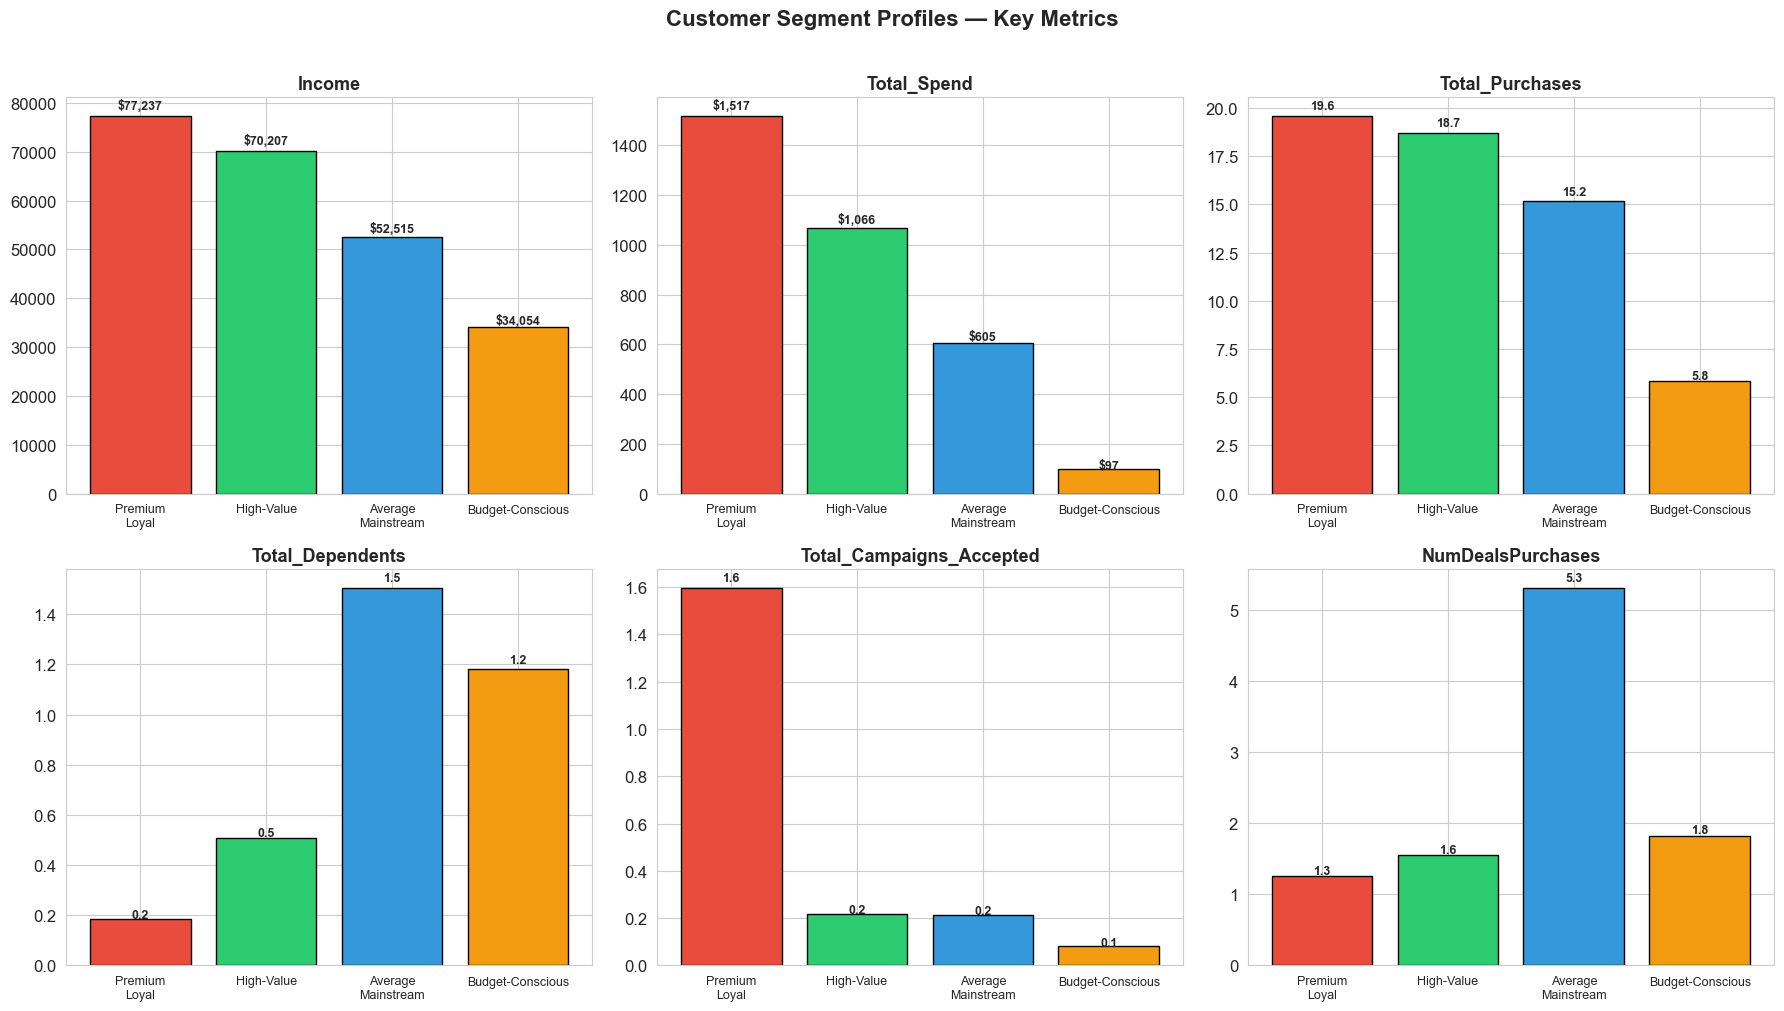


FINAL CUSTOMER SEGMENTATION RESULTS

Premium Loyal (227 customers | 10.2%)
  Income: $77,237  |  Spend: $1,517  |  Purchases: 19.6
  Dependents: 0.2  |  Campaigns: 1.59  |  Deals: 1.3

High-Value (627 customers | 28.0%)
  Income: $70,207  |  Spend: $1,066  |  Purchases: 18.7
  Dependents: 0.5  |  Campaigns: 0.22  |  Deals: 1.6

Average Mainstream (409 customers | 18.3%)
  Income: $52,515  |  Spend: $605  |  Purchases: 15.2
  Dependents: 1.5  |  Campaigns: 0.21  |  Deals: 5.3

Budget-Conscious (973 customers | 43.5%)
  Income: $34,054  |  Spend: $97  |  Purchases: 5.8
  Dependents: 1.2  |  Campaigns: 0.08  |  Deals: 1.8


In [80]:
# Summary bar chart — key metrics per segment (presentation-ready)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

summary_features = ['Income', 'Total_Spend', 'Total_Purchases', 
                    'Total_Dependents', 'Total_Campaigns_Accepted', 'NumDealsPurchases']
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

# Sort by Income for consistent ordering
label_order = df.groupby('Cluster_Label')['Income'].mean().sort_values(ascending=False).index

for i, col in enumerate(summary_features):
    means = df.groupby('Cluster_Label')[col].mean().reindex(label_order)
    bars = axes[i].bar(range(len(means)), means.values, color=colors[:len(means)], edgecolor='black')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xticks(range(len(means)))
    axes[i].set_xticklabels([l.replace(' ', '\n') for l in means.index], fontsize=9)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if col == 'Income':
            label = f'${height:,.0f}'
        elif col == 'Total_Spend':
            label = f'${height:,.0f}'
        else:
            label = f'{height:.1f}'
        axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                     label, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segment Profiles — Key Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print a clean final summary table
print('\n' + '='*80)
print('FINAL CUSTOMER SEGMENTATION RESULTS')
print('='*80)
for label in label_order:
    seg = df[df['Cluster_Label'] == label]
    print(f'\n{label} ({len(seg)} customers | {len(seg)/len(df)*100:.1f}%)')
    print(f'  Income: ${seg["Income"].mean():,.0f}  |  Spend: ${seg["Total_Spend"].mean():,.0f}  |  '
          f'Purchases: {seg["Total_Purchases"].mean():.1f}')
    print(f'  Dependents: {seg["Total_Dependents"].mean():.1f}  |  '
          f'Campaigns: {seg["Total_Campaigns_Accepted"].mean():.2f}  |  '
          f'Deals: {seg["NumDealsPurchases"].mean():.1f}')

## Step 7: Save Model & Clustered Data

Save the trained model artifacts and clustered dataset for the final presentation.

In [81]:
# Save model artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
print('Model artifacts saved:')
print('  scaler.pkl — StandardScaler')
print('  kmeans_model.pkl — Trained KMeans model')

# Save clustered dataset
df.to_csv('customer_segmentation_clustered.csv', index=False)
print(f'\nClustered dataset saved: customer_segmentation_clustered.csv')
print(f'  Shape: {df.shape}')

Model artifacts saved:
  scaler.pkl — StandardScaler
  kmeans_model.pkl — Trained KMeans model

Clustered dataset saved: customer_segmentation_clustered.csv
  Shape: (2236, 14)


In [83]:
# Final summary
print('='*60)
print('         MODEL BUILDING SUMMARY')
print('='*60)
print(f'Algorithm:          K-Means Clustering')
print(f'Number of Clusters: {CHOSEN_K}')
print(f'Silhouette Score:   {final_sil:.4f}')
print(f'Features Used:      {len(df.columns) - 2} (excluding Cluster & Cluster_Label)')
print(f'Total Customers:    {len(df)}')
print(f'\nCustomer Segments:')
for label in df.groupby('Cluster_Label')['Income'].mean().sort_values(ascending=False).index:
    count = (df['Cluster_Label'] == label).sum()
    print(f'  {label}: {count} ({count/len(df)*100:.1f}%)')
print(f'\nFiles Saved:')
print(f'  scaler.pkl')
print(f'  kmeans_model.pkl')
print(f'  customer_segmentation_clustered.csv')
print('='*60)

         MODEL BUILDING SUMMARY
Algorithm:          K-Means Clustering
Number of Clusters: 4
Silhouette Score:   0.1783
Features Used:      12 (excluding Cluster & Cluster_Label)
Total Customers:    2236

Customer Segments:
  Premium Loyal: 227 (10.2%)
  High-Value: 627 (28.0%)
  Average Mainstream: 409 (18.3%)
  Budget-Conscious: 973 (43.5%)

Files Saved:
  scaler.pkl
  kmeans_model.pkl
  customer_segmentation_clustered.csv
